# Potential Customer Prediction




# Summary
This project predicts potential customer conversion for a company using demographic and engagement data. It applies a robust methodology involving data preprocessing, feature engineering, and training of multiple classification models, including Logistic Regression, Random Forest, and XGBoost. The analysis identifies key predictors such as time spent on the website and profile completion, while revealing that some metrics, like website visits, are less indicative of intent. The final model was selected based on a balanced evaluation of precision and recall. Explainable AI techniques were used to interpret model outputs and highlight important features, providing actionable insights for targeted marketing and business strategy.

## Prerequisites

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report
)
import shap

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("ExtraaLearn.csv")

## Data Overview

In [4]:
df.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [5]:
df.shape

(4612, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

In [7]:
df.isna().sum()

ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64

In [8]:
df.dropna(thresh=df.shape[1] // 2, inplace=True)

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop_duplicates(inplace=True)

## Exploratory Data Analysis

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [12]:
cat_col = list(df.select_dtypes("object").columns)

# Number of count of each unique value in each column
for column in cat_col:
    print(df[column].value_counts())
    print("-" * 50)

ID
EXT001     1
EXT2884    1
EXT3080    1
EXT3079    1
EXT3078    1
          ..
EXT1537    1
EXT1536    1
EXT1535    1
EXT1534    1
EXT4612    1
Name: count, Length: 4612, dtype: int64
--------------------------------------------------
current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
--------------------------------------------------
first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64
--------------------------------------------------
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
--------------------------------------------------
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
--------------------------------------------------
print_media_type2
No     4379
Yes     233
Name

In [13]:
df["ID"].nunique()

4612

In [14]:
df.drop(["ID"], axis=1, inplace=True)

In [15]:
def histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(
        data=df, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    if bins:
        sns.histplot(
            data=df, x=feature, kde=kde, ax=ax_hist2, bins=bins, color="skyblue"
        )
    else:
        sns.histplot(
            data=df, x=feature, kde=kde, ax=ax_hist2, color="skyblue"
        )
    ax_hist2.axvline(df[feature].mean(), color="green", linestyle="--")
    ax_hist2.axvline(df[feature].median(), color="black", linestyle="-")
    ax_hist2.axvline(df[feature].mode()[0], color="red", linestyle="-")

    plt.tight_layout()
    plt.show()


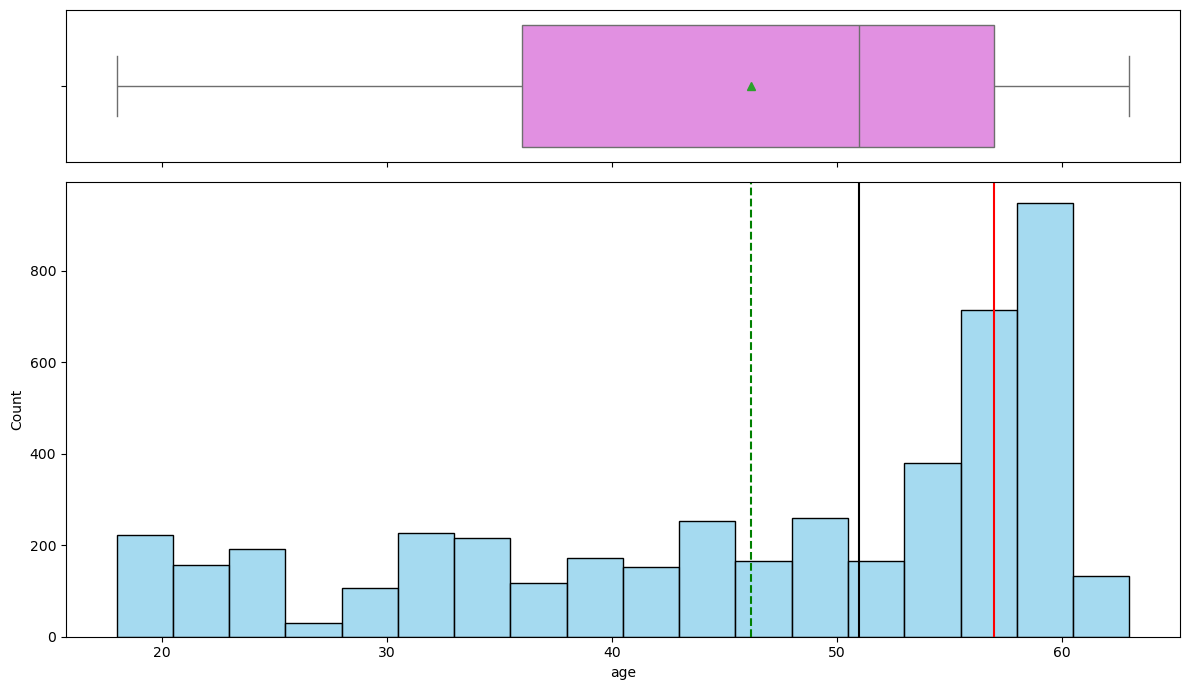

In [16]:
histogram_boxplot(df, "age") 

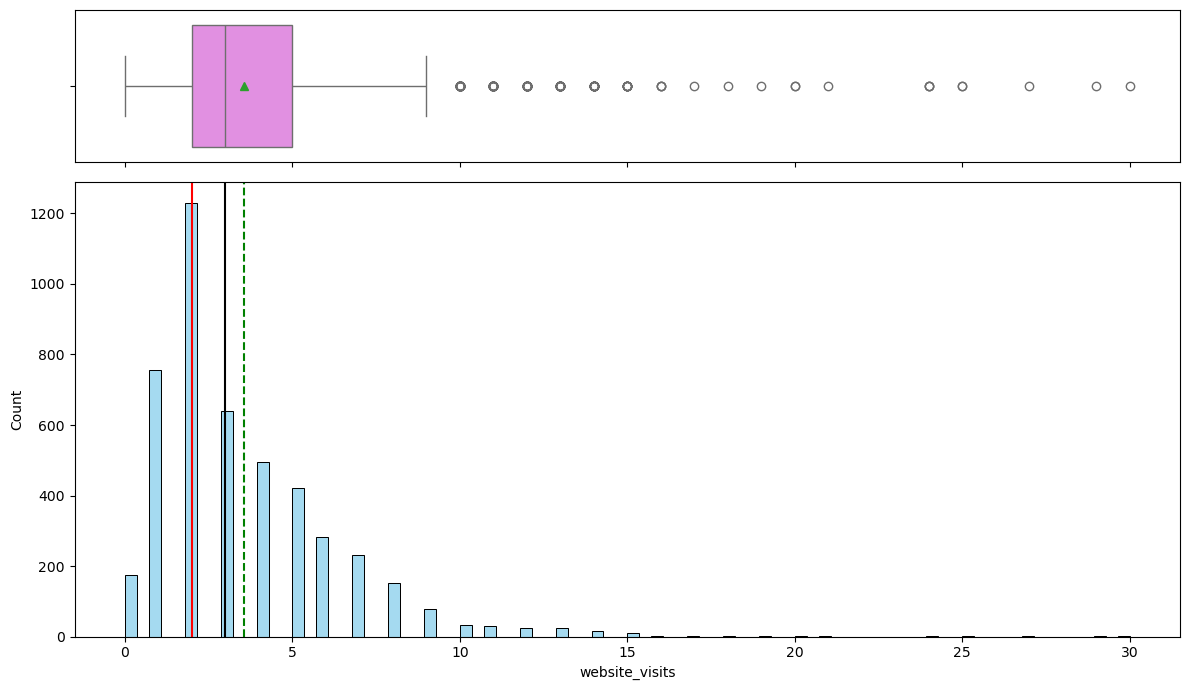

In [17]:
histogram_boxplot(df, "website_visits")

In [18]:
# To check how many leads have not visited web-site
df[df["website_visits"] == 0].shape

(174, 14)

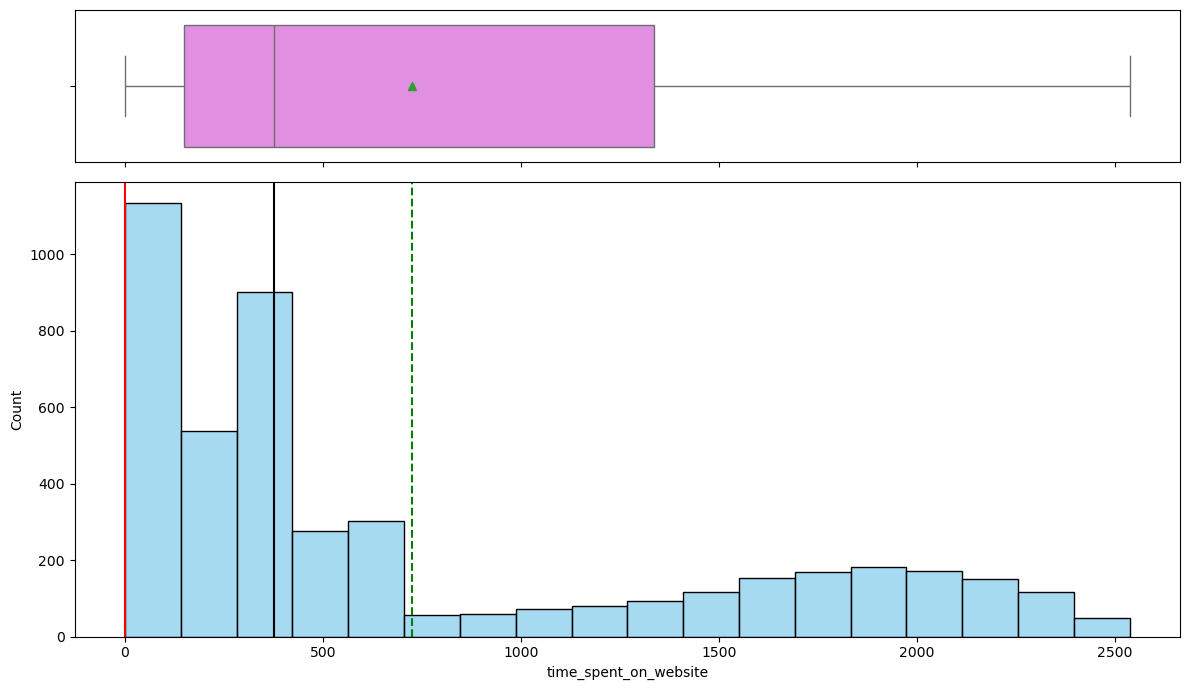

In [19]:
histogram_boxplot(df, "time_spent_on_website")

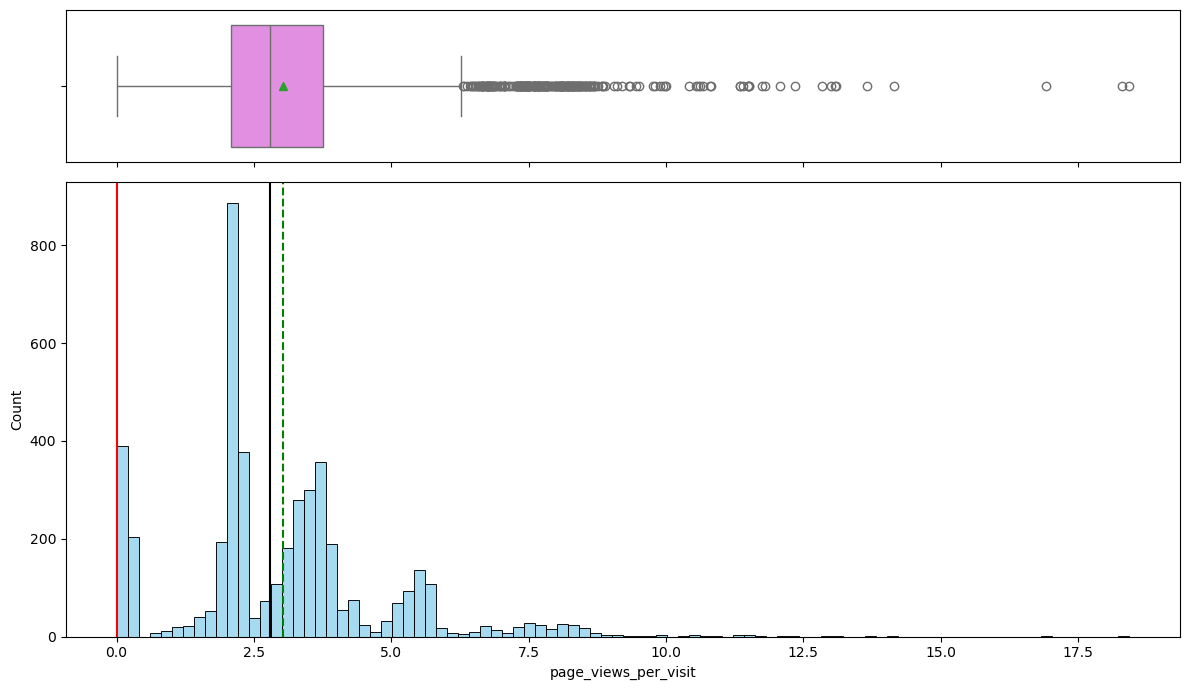

In [20]:
histogram_boxplot(df, "page_views_per_visit")


**Observations:**
- Age Distribution: The distribution of potential customers' ages is bimodal, with two significant peaks. A substantial group falls in the late 50s, and a smaller, but still notable, group is in their early 20s. The overall age range is broad, but the majority of customers are over 50. The median age is approximately 45, indicating a slight skew towards the older demographic. This suggests you may need to tailor your marketing efforts to appeal to both younger adults and a more mature audience.
- Website Visits: The data for website visits is heavily concentrated at the lower end. The majority of potential customers visit the site 1 to 3 times. The distribution is highly skewed to the right, with a long tail of outliers indicating a small number of users who visit the site more than 10 times. The median number of visits is very low, around 2, suggesting that most customers are not repeat visitors. This could mean either a high-conversion, low-consideration product or a need to improve strategies to encourage return visits.

- Time Spent on Website: The distribution for time spent on the website is also skewed. A large portion of users spend very little time on the site, with a peak near the 200-second mark. However, there's a smaller, but significant, group of users who spend a considerable amount of time, with some staying for over 2000 seconds. The median time spent is quite low, around 350 seconds. This suggests two distinct user behaviors: a large group of quick visitors and a smaller segment of highly engaged users.

- Page Views Per Visit: The page views per visit graph shows a similar pattern to website visits, with a strong peak at 2-3 page views. This indicates that most users are exploring only a few pages before leaving. The median is just over 2. The distribution is heavily skewed right, with numerous outliers, showing that a few users view many pages, possibly indicating a deep interest in the product. However, the majority of visitors are not engaging in extensive Browse.

In [21]:
def labeled_barplot(df, feature, perc=False, n=10):

    plt.figure(figsize=(n + 1, 10))
    plt.xticks(rotation=90, fontsize=15)

    order = df[feature].value_counts().index[:n]
    ax = sns.countplot(
        data=df,
        x=feature,
        palette="Paired",
        order=order
    )

    total = len(df)
    for p in ax.patches:
        count = int(p.get_height())
        if perc:
            label = f'{100 * count / total:.1f}%'
        else:
            label = f'{count}'
        ax.annotate(label, (p.get_x() + p.get_width() / 2., count),
                    ha='center', va='center', fontsize=12,
                    xytext=(0, 10), textcoords='offset points')

    plt.tight_layout()
    plt.show()


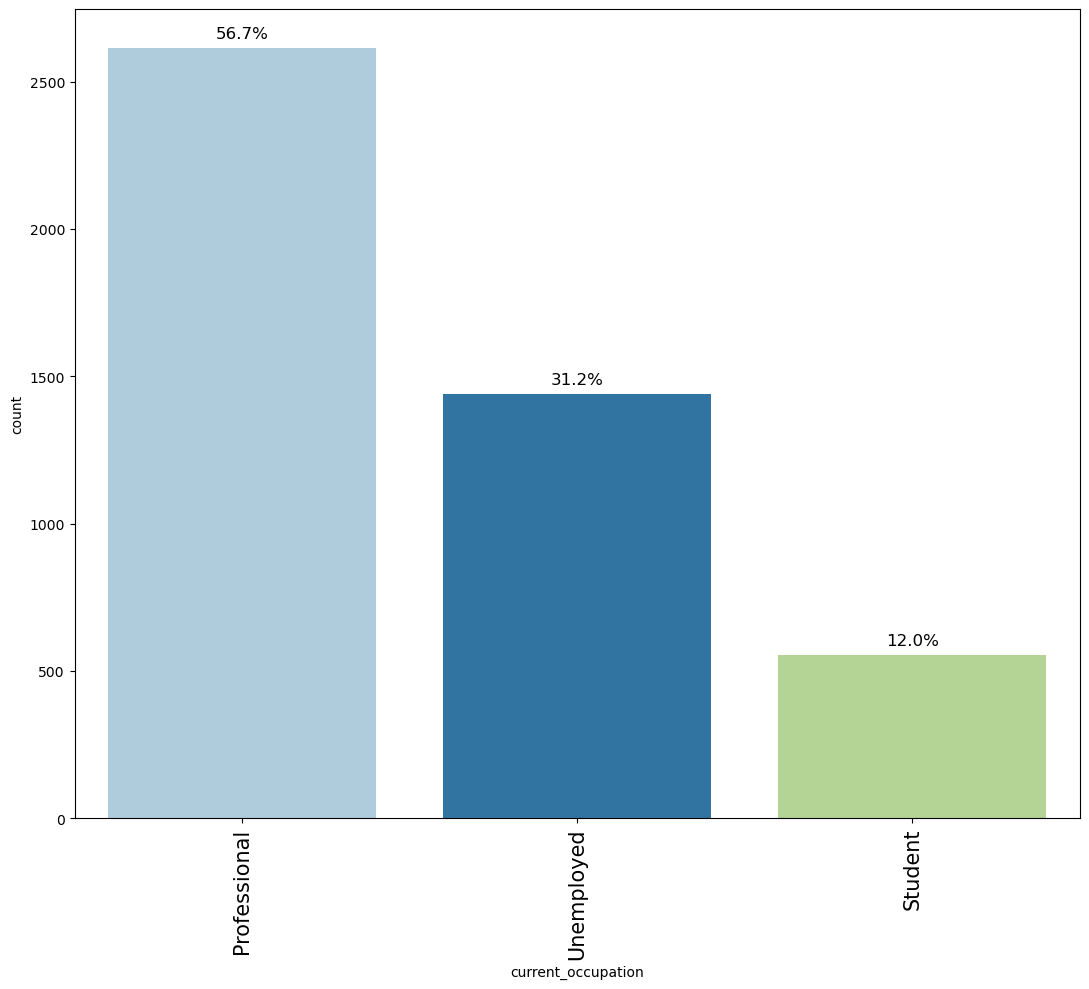

In [22]:
labeled_barplot(df, "current_occupation", perc=True)

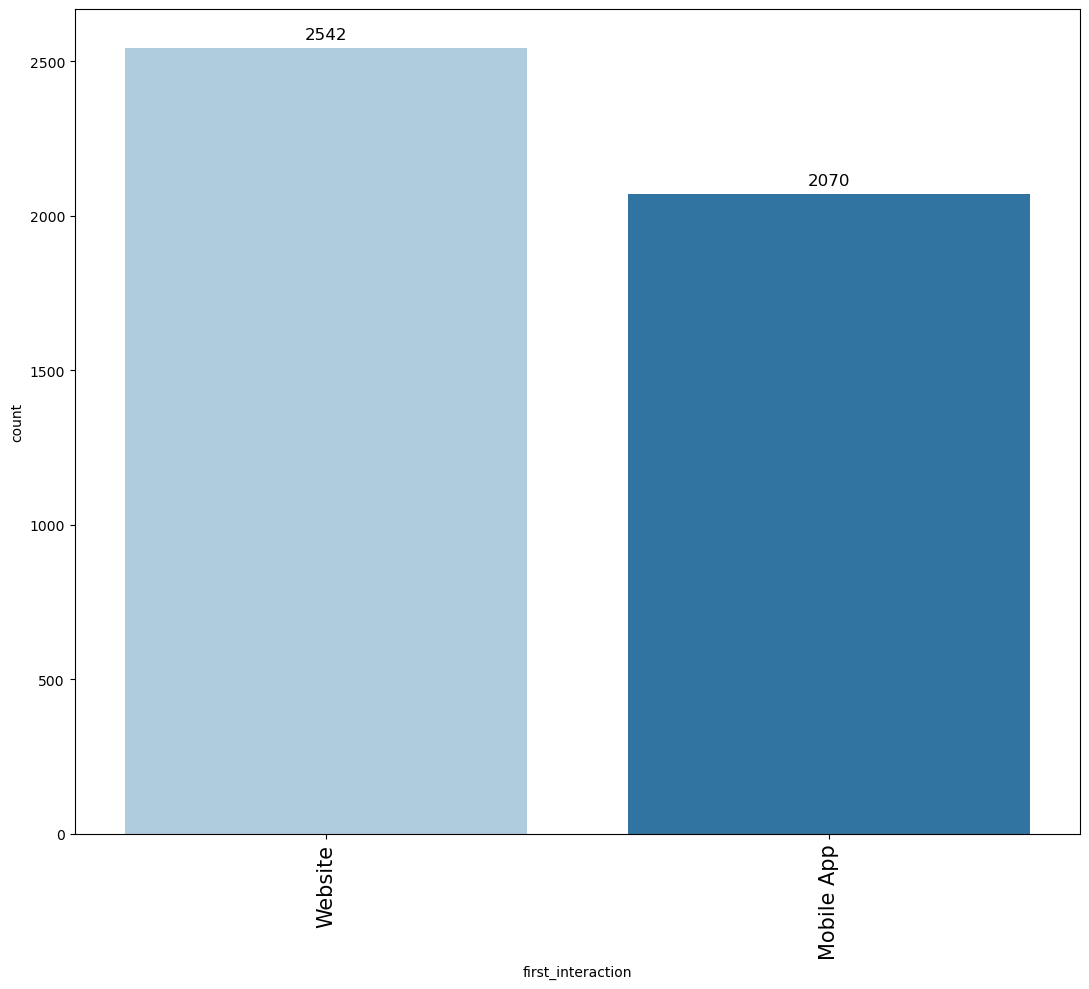

In [23]:
labeled_barplot(df, "first_interaction")

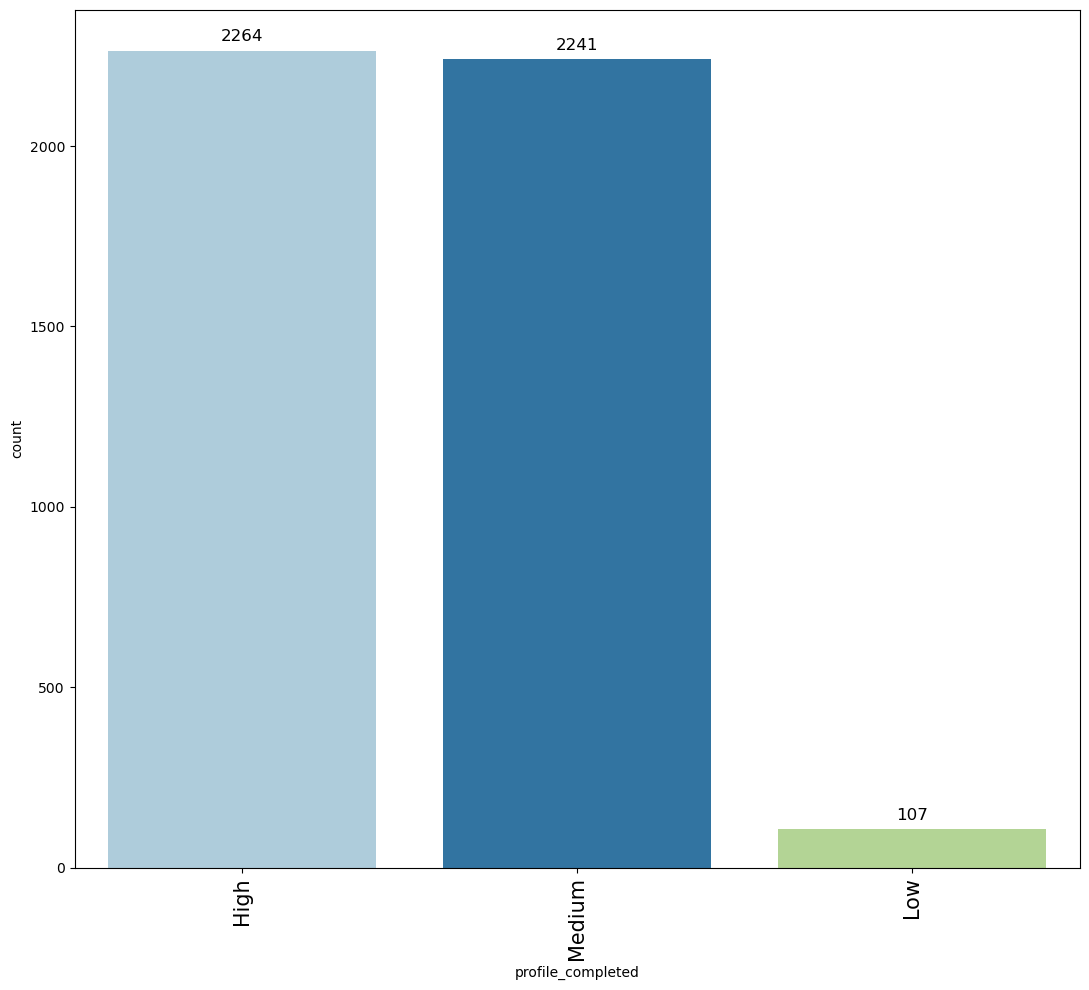

In [24]:
labeled_barplot(df, "profile_completed")

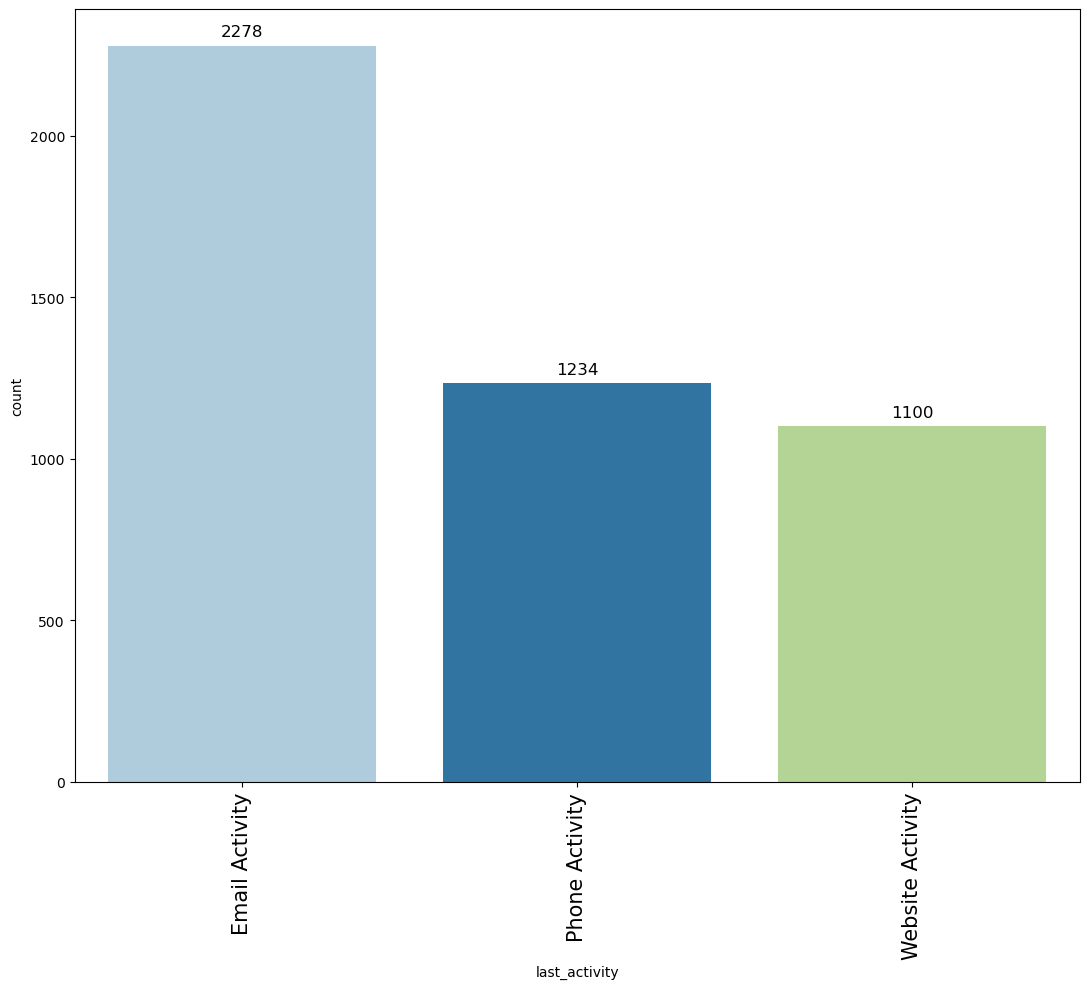

In [25]:
labeled_barplot(df, "last_activity") 

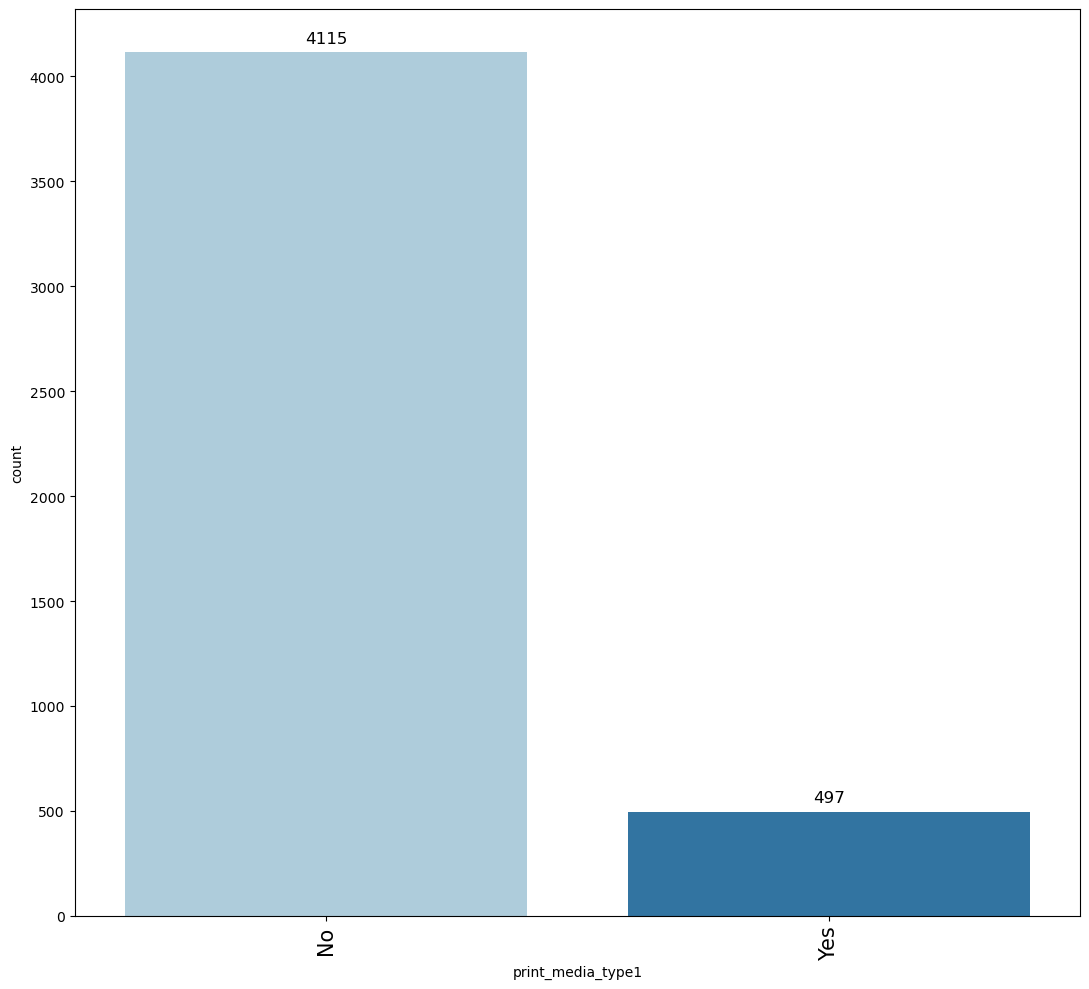

In [26]:
labeled_barplot(df, "print_media_type1") 

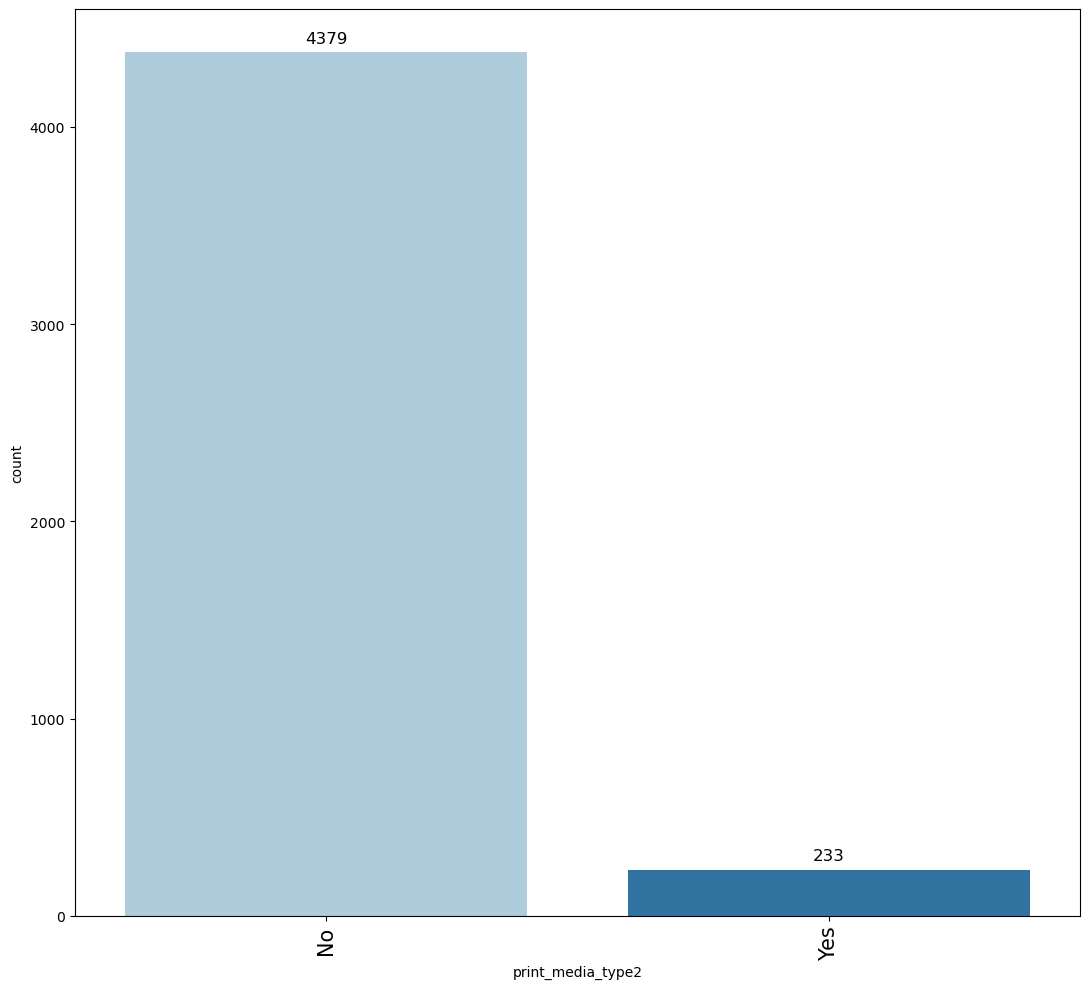

In [27]:
labeled_barplot(df, "print_media_type2") 

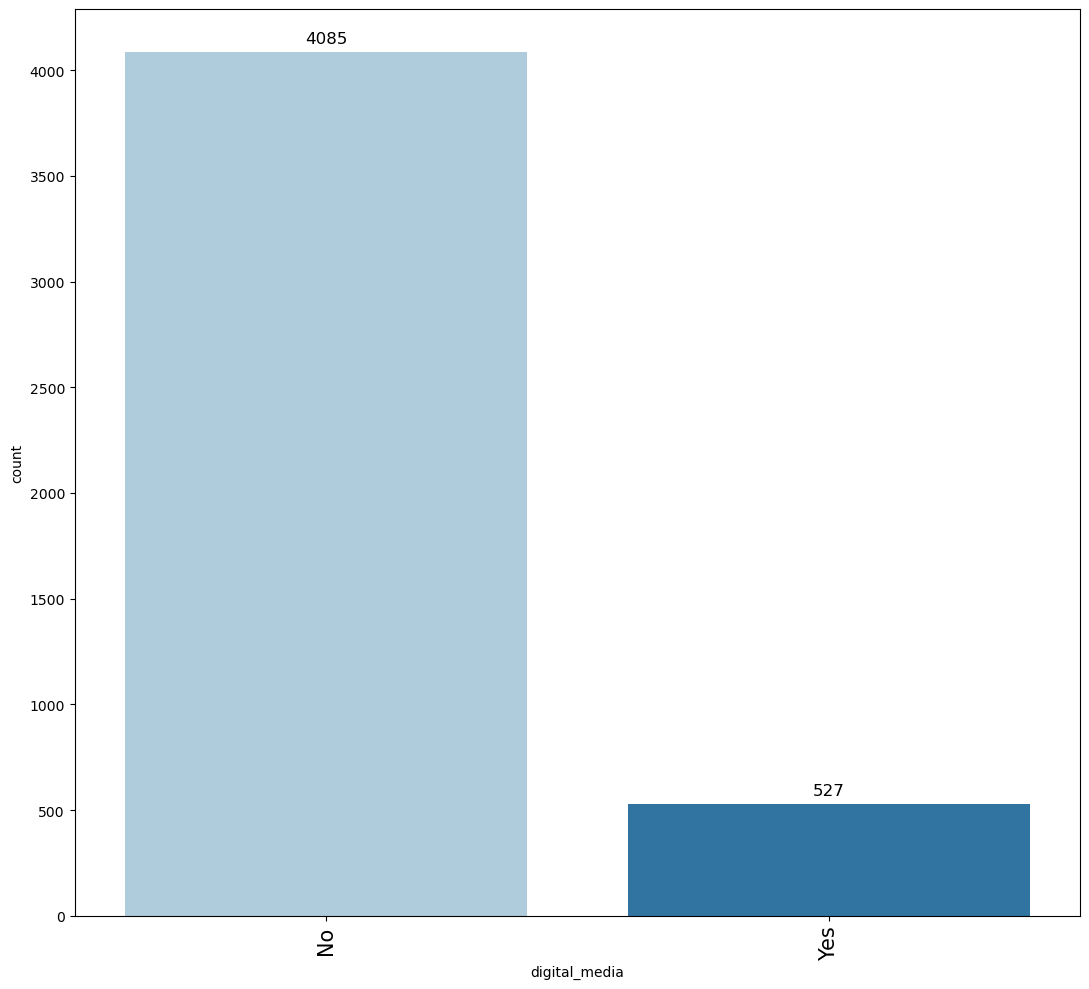

In [28]:
labeled_barplot(df, "digital_media")

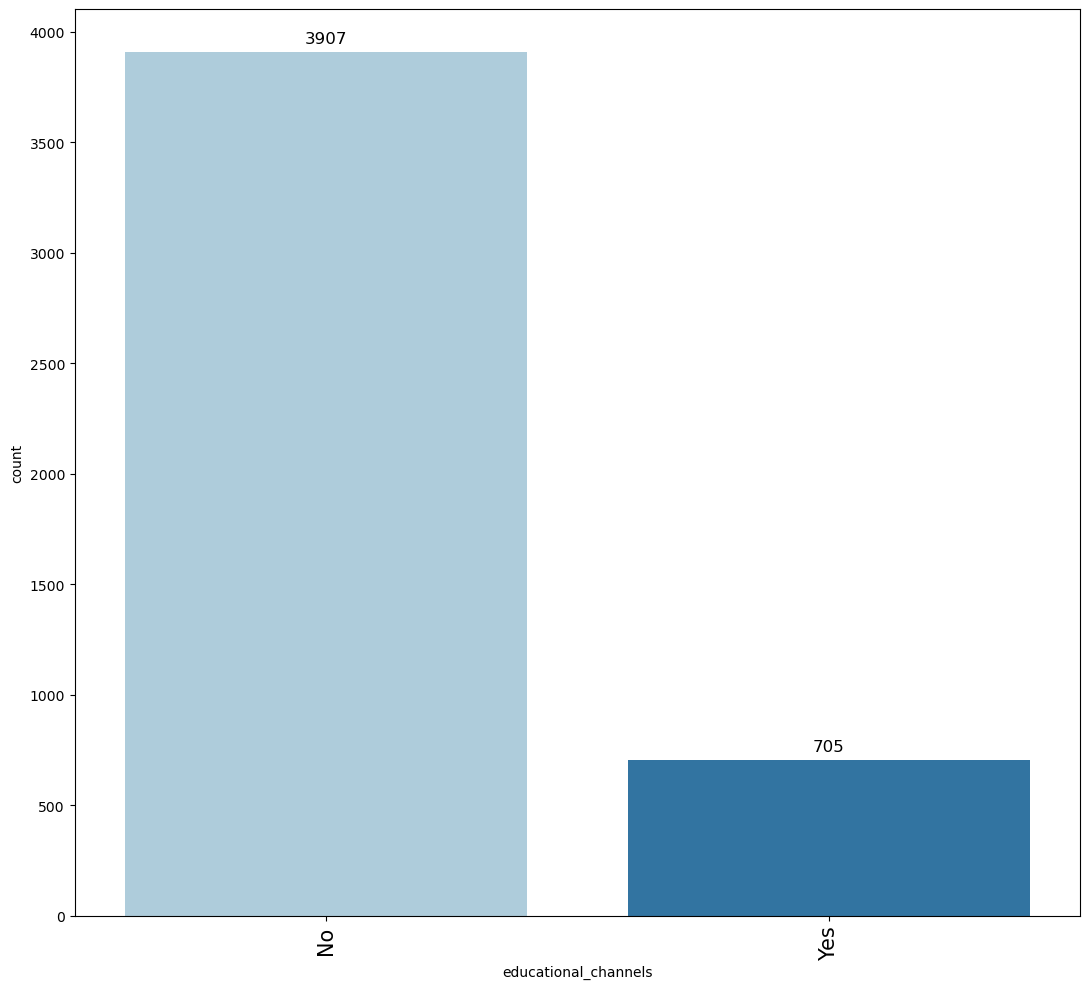

In [29]:
labeled_barplot(df, "educational_channels")

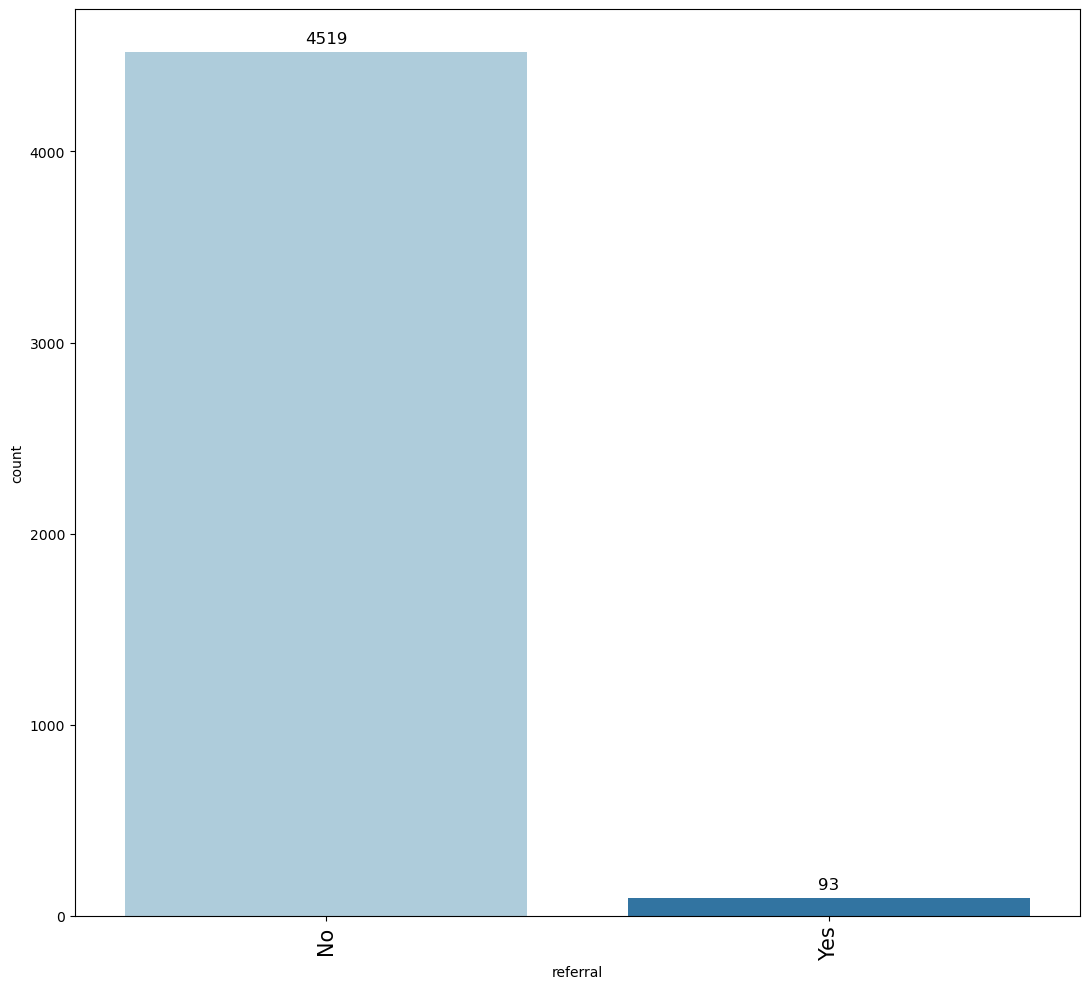

In [30]:
labeled_barplot(df, "referral")

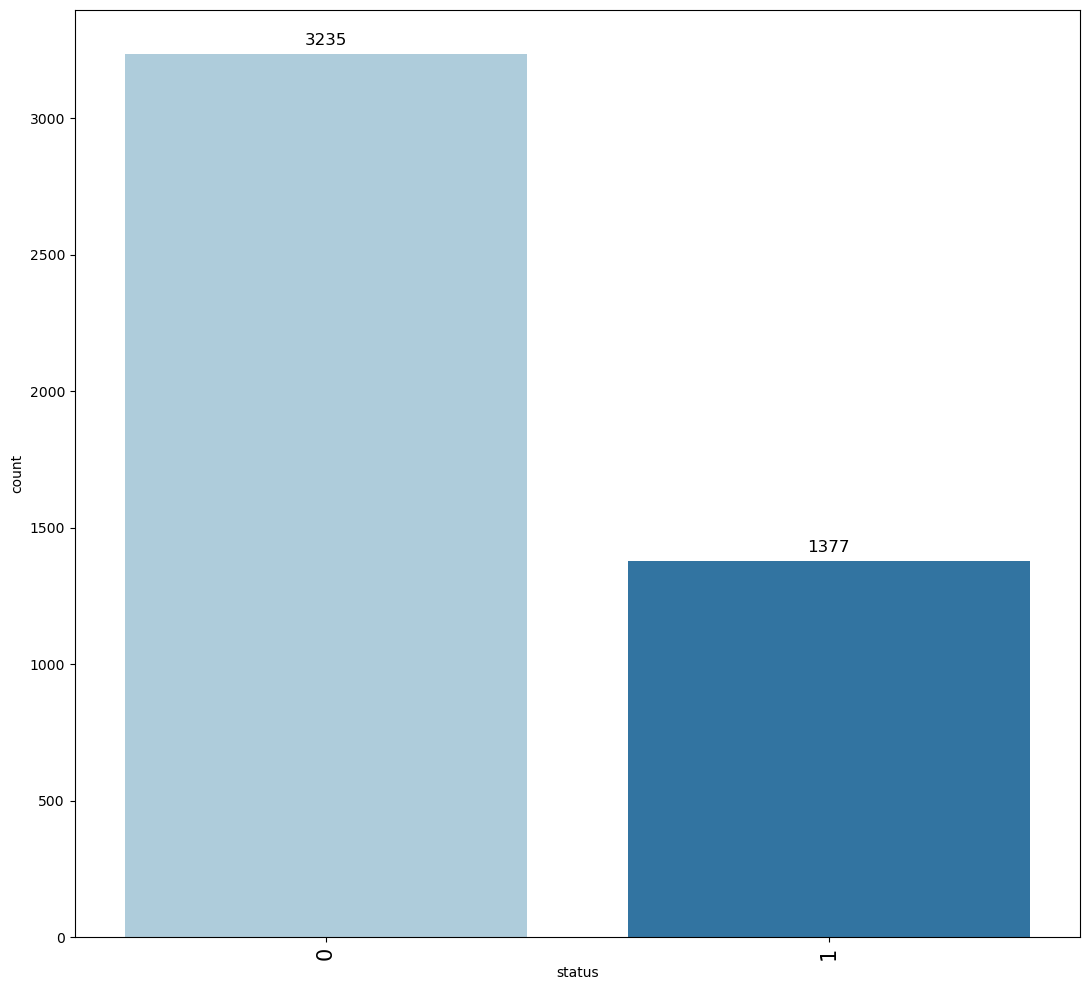

In [31]:
labeled_barplot(df, "status")

**Observations:**
- Customer Demographics and Engagement
  - Occupation: The majority of potential customers are professionals (56.7%). Unemployed individuals make up a significant second group (31.2%), while students represent a smaller portion (12.0%). This highlights professionals as the core audience, but also shows a notable segment of non-working individuals.

  - Profile Completion: Most profiles are either high (2264) or medium (2241) in completeness, with very few being low (107). This suggests that potential customers are generally willing to provide information, indicating a high level of initial engagement.

  - First Interaction: The first point of contact is almost evenly split between the website (2542) and the mobile app (2070). This shows that both platforms are crucial for acquiring new leads, and neither should be neglected.

  - Last Activity: The most common last activity is email activity (2278), followed by phone activity (1234) and then website activity (1100). This indicates that email is a primary channel for communication and engagement.

- Marketing and Communication Channels
  - Print Media: There's a very low response to both types of print media. For print_media_type1, only 497 out of 4612 people responded "Yes". For print_media_type2, the number is even lower at 233. This suggests that print media is not an effective channel for reaching this audience.

  - Digital Media: Similar to print media, a small number of potential customers responded to digital media, with only 527 saying "Yes". While slightly better than print, it's still a small fraction of the total.

  - Educational Channels: The use of educational channels is low, with only 705 people responding "Yes" out of a total of 4612. This indicates that a minority of the audience is being reached through these channels.

  - Referrals: Referrals are an almost negligible source of new customers. Only 93 people were acquired through a referral, which is an extremely small number compared to the total. This suggests that word-of-mouth isn't a strong driver for this customer base.

  - Status: The final graph, representing status, shows that the majority of leads have a status of 0 (3235), while a smaller but still substantial number have a status of 1 (1377). This suggests a significant portion of potential customers are not converting, and there's a clear opportunity to improve conversion rates.


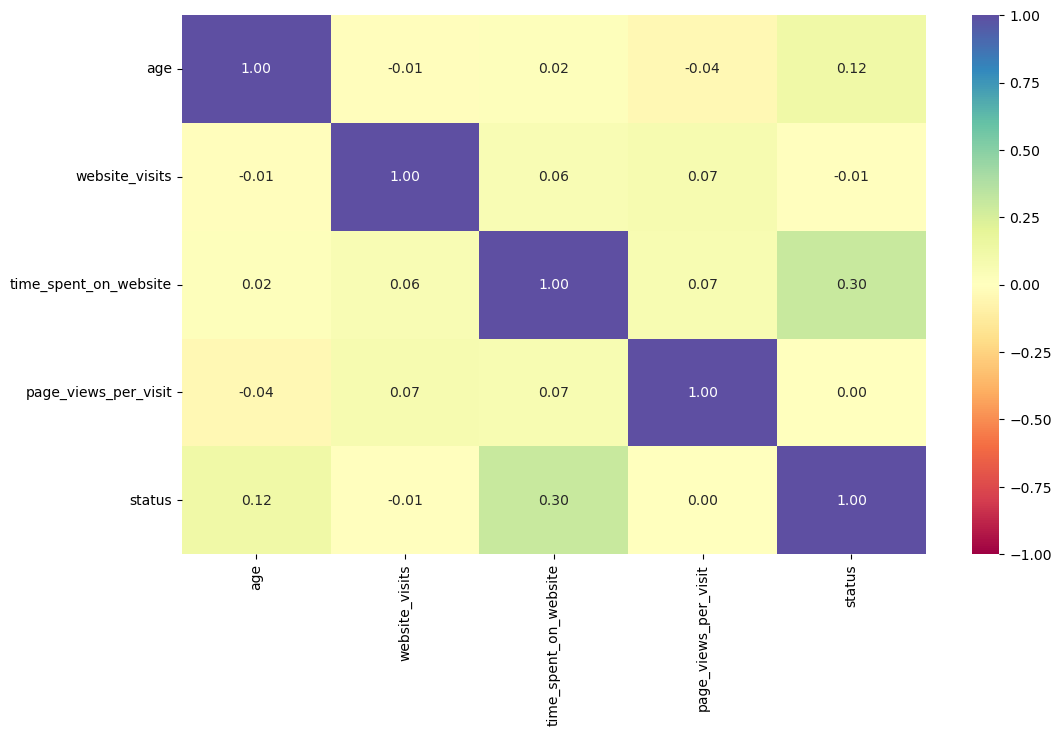

In [32]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Observations:**
- Time Spent on Website has the strongest positive correlation with status (0.30). This indicates that the more time a potential customer spends on the website, the more likely they are to convert. This is a significant finding and suggests that engagement is a key driver for conversion.

- Age has a weak positive correlation with status (0.12). This suggests that older potential customers are slightly more likely to convert.

- Website Visits and Page Views Per Visit show almost no correlation with status (-0.01 and 0.00, respectively). This is a crucial insight, as it means simply having a user visit your site multiple times or view many pages isn't a good predictor of conversion. Quality of engagement (time spent) is more important than quantity (visits/pages viewed).
- Overall, there are no strong correlations between the independent variables. This is a good sign, as it means there is little multicollinearity, and each feature provides unique information for predicting conversion. The data shows that the primary driver for conversion is the depth of engagement (time spent), not the frequency or breadth of it.

In [33]:
def distribution_plot_wrt_target(df, predictor, target):
    
    target_uniq = df[target].dropna().unique()
    
    fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    axs[0].set_title(f"Distribution for {target} = {target_uniq[0]}")
    sns.histplot(
        data=df[df[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0],
        color="teal",
        stat="density"
    )

    axs[1].set_title(f"Distribution for {target} = {target_uniq[1]}")
    sns.histplot(
        data=df[df[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[1],
        color="orange",
        stat="density"
    )

    plt.tight_layout()
    plt.show()


In [34]:
def stacked_barplot(df, predictor, target):
    count = df[predictor].nunique()
    sorter = df[target].value_counts().index[-1]
    tab1 = pd.crosstab(df[predictor], df[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(df[predictor], df[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

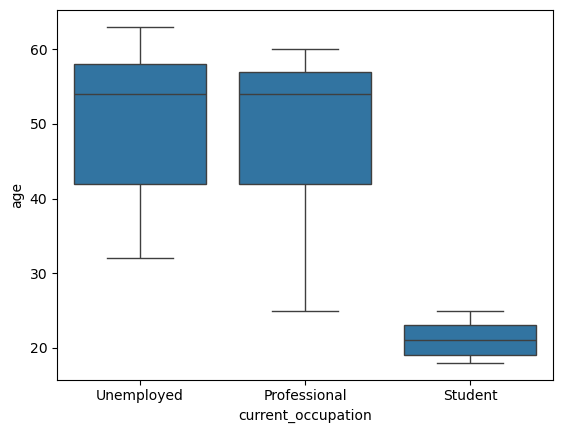

<Figure size 1000x500 with 0 Axes>

In [35]:
sns.boxplot(x="current_occupation", y="age", data=df)
plt.figure(figsize=(10, 5))
plt.show()


In [36]:
df.groupby(["current_occupation"])["age"].describe()

,count,mean,std,min,25%,50%,75%,max
current_occupation,,,,,,,,
Professional,2616.0,49.347477,9.890744,25.0,42.0,54.0,57.0,60.0
Student,555.0,21.144144,2.001114,18.0,19.0,21.0,23.0,25.0
Unemployed,1441.0,50.140180,9.999503,32.0,42.0,54.0,58.0,63.0


**Observations:**
- Professionals and Unemployed Individuals: These two groups have very similar age distributions. The median age for both is in the mid-50s (54 for both groups). The interquartile range (IQR) for both groups spans from around 42 to 58. This suggests that the majority of your professional and unemployed customers are in a mature age bracket.

- Students: As expected, the student group is significantly younger. Their median age is 21, with the majority of students falling between 19 and 23 years old. This group has a much tighter age range and a lower average age compared to the other two categories.

The primary distinction is the vast age gap between the student segment and the other two segments. The boxplots for professionals and unemployed individuals are positioned similarly and higher up the age axis, while the boxplot for students is much lower. This reinforces the need for different marketing strategies and messaging for each distinct age group.

status                 0     1   All
current_occupation                  
All                 3235  1377  4612
Professional        1687   929  2616
Unemployed          1058   383  1441
Student              490    65   555
------------------------------------------------------------------------------------------------------------------------


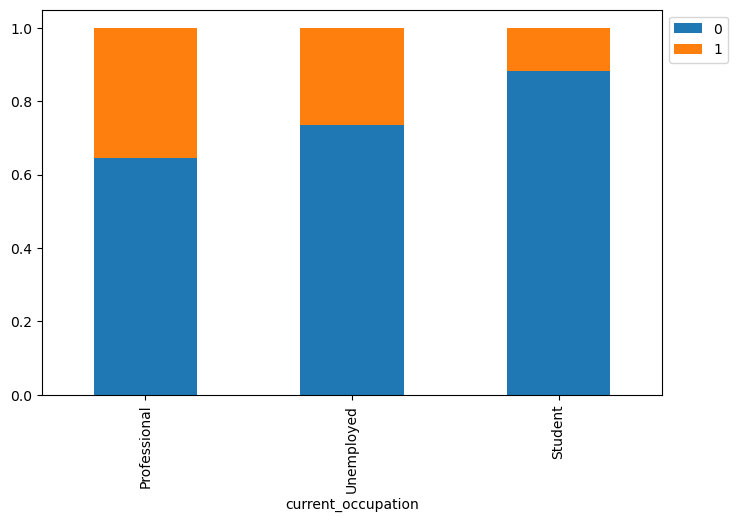

In [37]:
stacked_barplot(df, "current_occupation", "status")

status                0     1   All
first_interaction                  
All                3235  1377  4612
Website            1383  1159  2542
Mobile App         1852   218  2070
------------------------------------------------------------------------------------------------------------------------


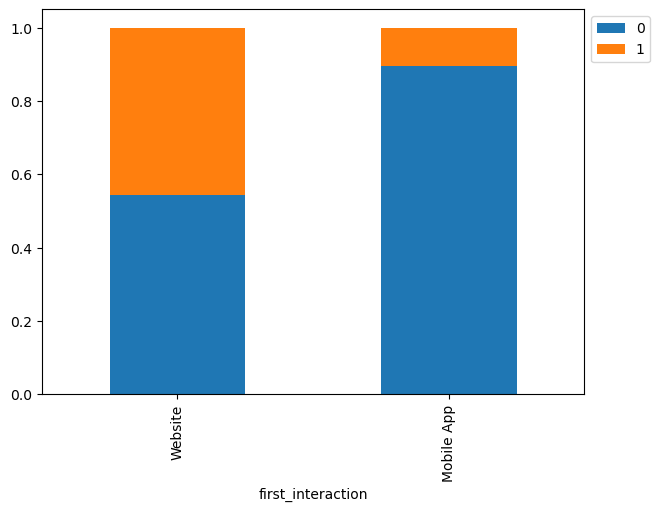

In [38]:
stacked_barplot(df, "first_interaction", "status")

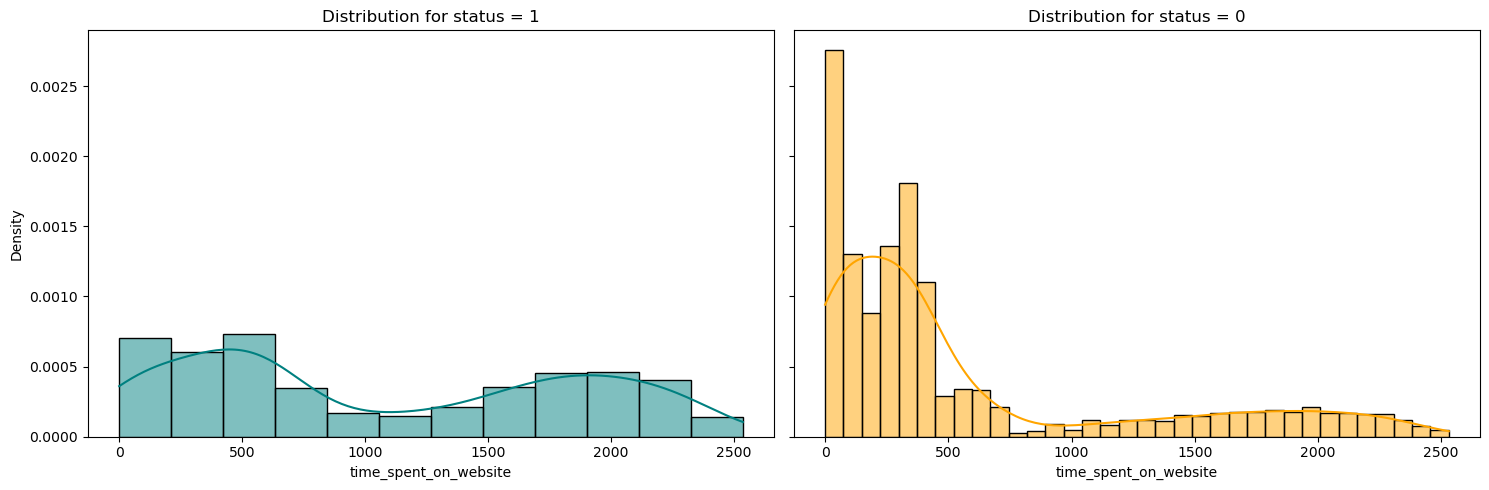

In [39]:
distribution_plot_wrt_target(df, "time_spent_on_website", "status")

In [40]:
# checking the median value
df.groupby(["status"])["time_spent_on_website"].median()

status
0    317.0
1    789.0
Name: time_spent_on_website, dtype: float64

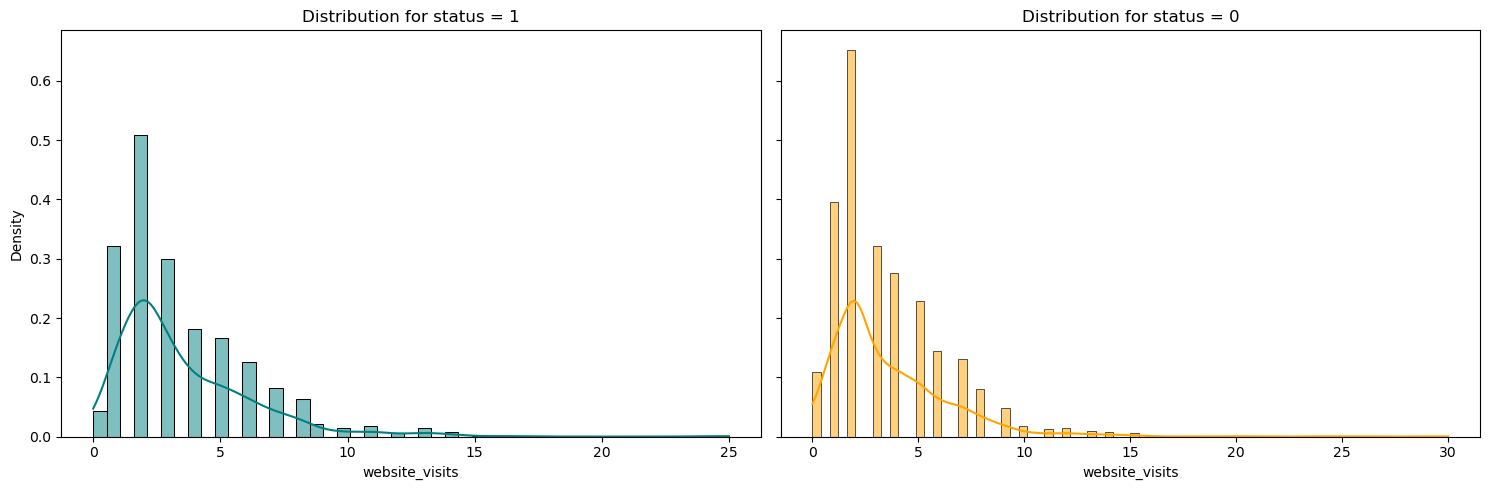

In [41]:
distribution_plot_wrt_target(df, "website_visits", "status")

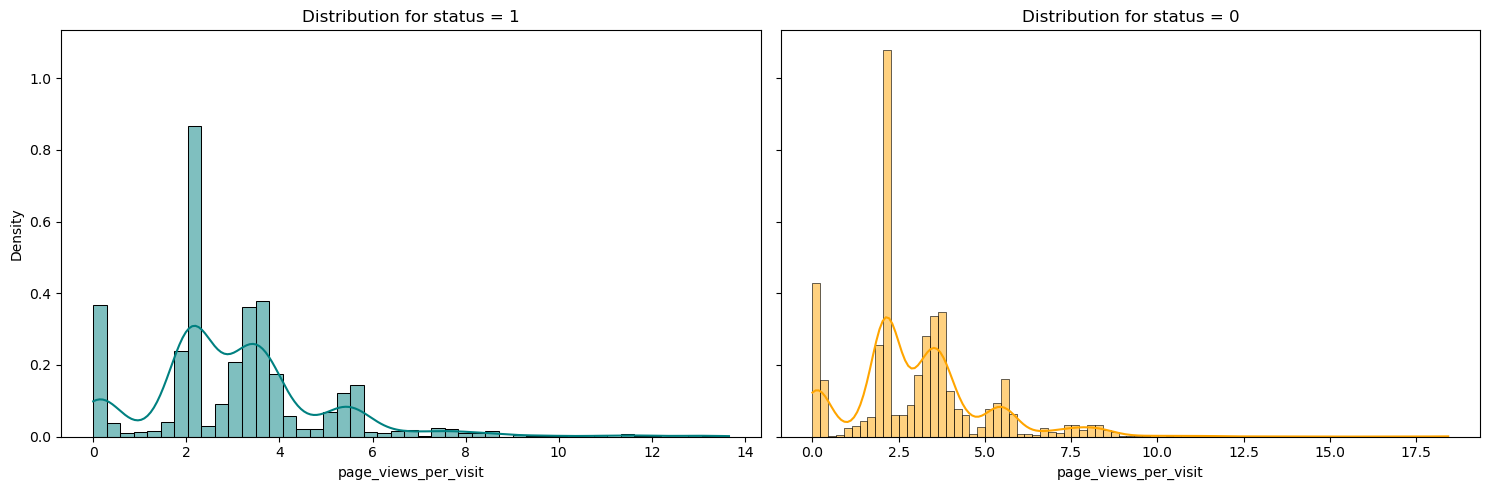

In [42]:
distribution_plot_wrt_target(df, "page_views_per_visit", "status")

status                0     1   All
profile_completed                  
All                3235  1377  4612
High               1318   946  2264
Medium             1818   423  2241
Low                  99     8   107
------------------------------------------------------------------------------------------------------------------------


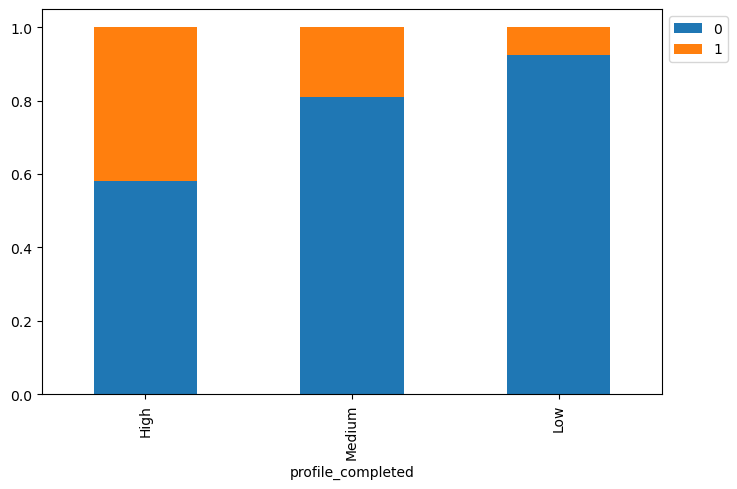

In [43]:
stacked_barplot(df, "profile_completed", "status")

status               0     1   All
last_activity                     
All               3235  1377  4612
Email Activity    1587   691  2278
Website Activity   677   423  1100
Phone Activity     971   263  1234
------------------------------------------------------------------------------------------------------------------------


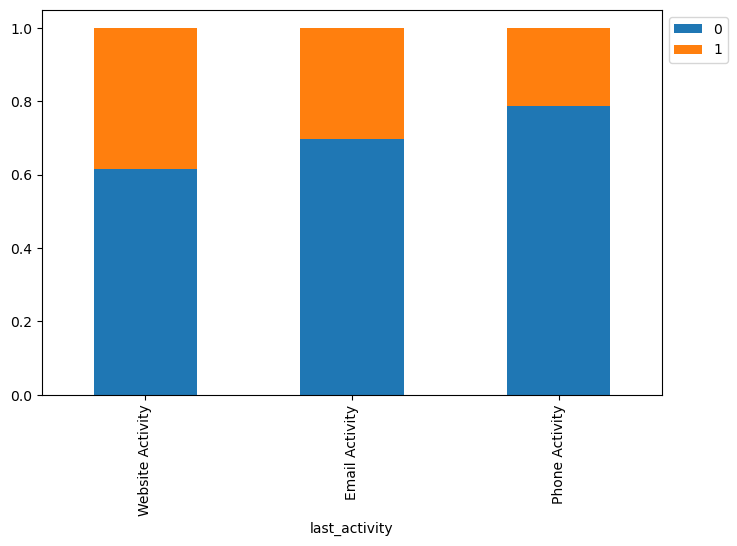

In [44]:
stacked_barplot(df, "last_activity", "status") 

status                0     1   All
print_media_type1                  
All                3235  1377  4612
No                 2897  1218  4115
Yes                 338   159   497
------------------------------------------------------------------------------------------------------------------------


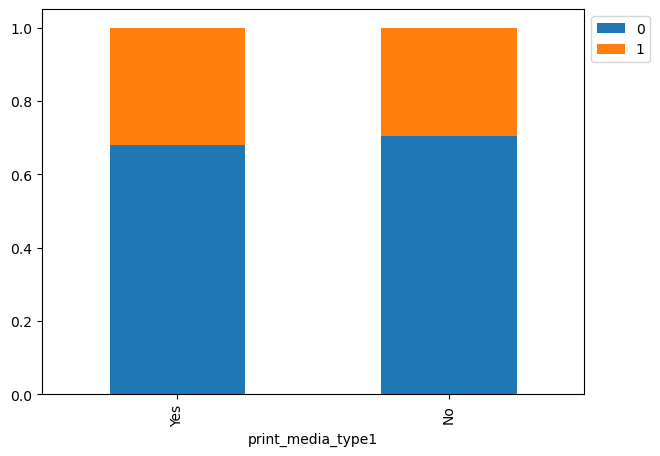

In [45]:
stacked_barplot(df, "print_media_type1", "status") 

status                0     1   All
print_media_type2                  
All                3235  1377  4612
No                 3077  1302  4379
Yes                 158    75   233
------------------------------------------------------------------------------------------------------------------------


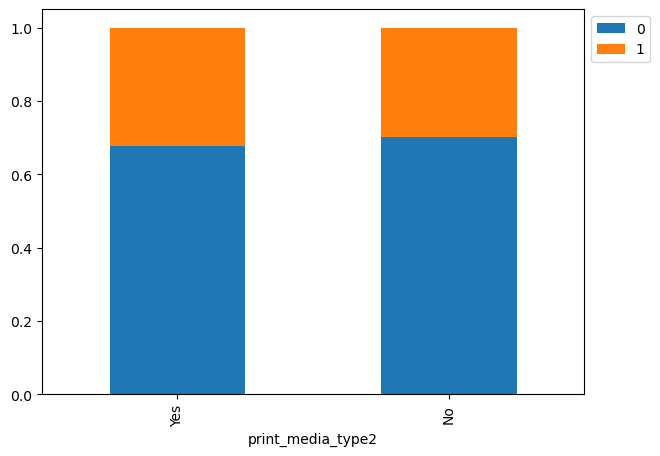

In [46]:
stacked_barplot(df, "print_media_type2", "status") 

status            0     1   All
digital_media                  
All            3235  1377  4612
No             2876  1209  4085
Yes             359   168   527
------------------------------------------------------------------------------------------------------------------------


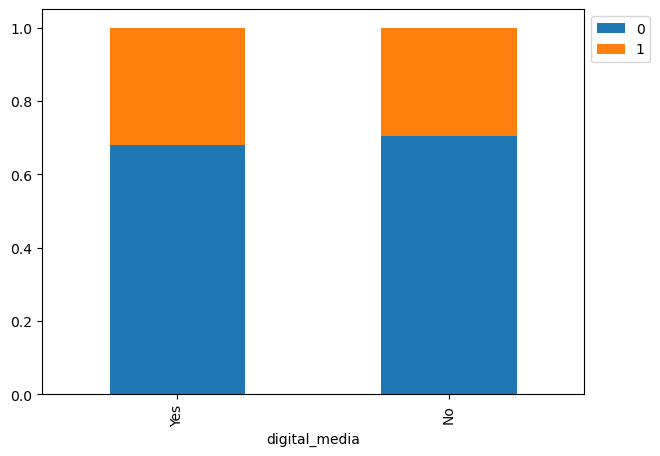

In [47]:
stacked_barplot(df, "digital_media", "status")

status                   0     1   All
educational_channels                  
All                   3235  1377  4612
No                    2727  1180  3907
Yes                    508   197   705
------------------------------------------------------------------------------------------------------------------------


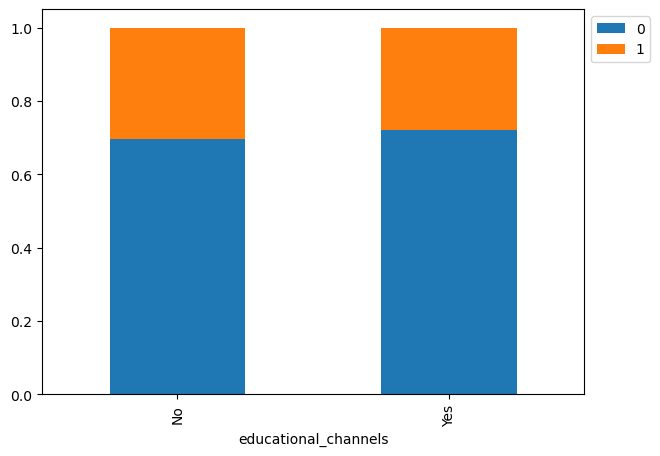

In [48]:
stacked_barplot(df, "educational_channels", "status") 

status       0     1   All
referral                  
All       3235  1377  4612
No        3205  1314  4519
Yes         30    63    93
------------------------------------------------------------------------------------------------------------------------


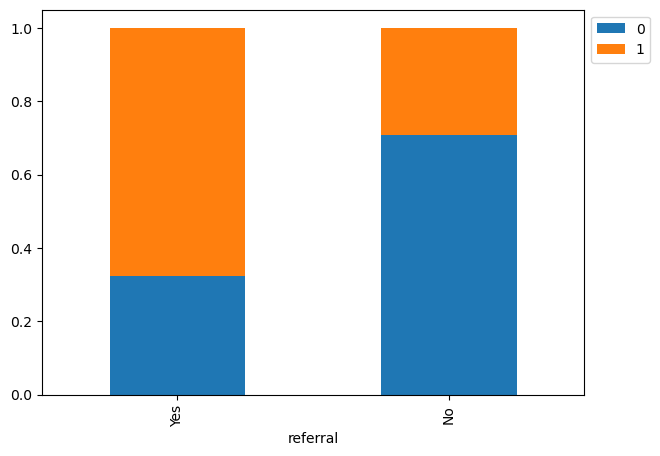

In [49]:
stacked_barplot(df, "referral", "status")

**Observations:**
- Website Engagement and Behavior
  - Time Spent on Website: The conversion rate is strongly tied to the time spent on the website. Converting customers (status=1) show a much more spread-out distribution of time spent, indicating they are willing to engage for longer periods. In contrast, non-converting customers (status=0) have a sharp peak at the lower end, showing they spend very little time on the site. This suggests that the depth of engagement, not just the visit itself, is a key driver of conversion.

  - Page Views Per Visit: A similar pattern to time spent on site emerges. Converting customers tend to view a higher number of pages (with a peak around 2-3 pages and a longer tail), while non-converting customers are concentrated at the very low end (1-2 pages viewed). This reinforces that active exploration is a strong indicator of a potential conversion.

  - Website Visits: The distributions for both converting and non-converting customers are almost identical, with the majority having only 1 or 2 visits. This shows that the number of website visits is not a reliable predictor of conversion.

- Customer Activities and Channels
  - First Interaction: The platform of first interaction significantly impacts conversion. Customers who first interact via the website have a higher conversion rate, while those who first interact via the mobile app have a much lower conversion rate. This is a critical finding, suggesting that the mobile app experience may be a bottleneck to conversion.

  - Last Activity: Customers whose last activity was on the website have the highest conversion rate. Those whose last activity was via email or phone have a significantly lower conversion rate. This suggests that direct website engagement is more likely to lead to a conversion than subsequent communications.

  - Educational Channels: The use of educational channels is not a strong indicator of conversion. The conversion rate for those who used educational channels is almost the same as for those who didn't.

  - Referral: Referrals appear to have a very high conversion rate. Customers who responded "Yes" to a referral are significantly more likely to convert than those who didn't. Although a small group, this shows that referred customers are a highly valuable segment.

  - Digital and Print Media: Both digital and print media seem to have a negligible impact on conversion rates. The conversion percentages for "Yes" and "No" for both types of media are nearly identical.

  - Profile Completion: Customers with a high profile completion are the most likely to convert. The conversion rate for those with a low completion rate is significantly lower. This suggests that a customer's willingness to provide information is a good proxy for their level of interest and intent to convert.

- Customer Demographics
  - Current Occupation: This is a strong predictor of conversion. Professionals have the highest conversion rate. The conversion rates for unemployed individuals and students are significantly lower. This indicates that professionals are your most valuable target demographic.

### Outlier Check

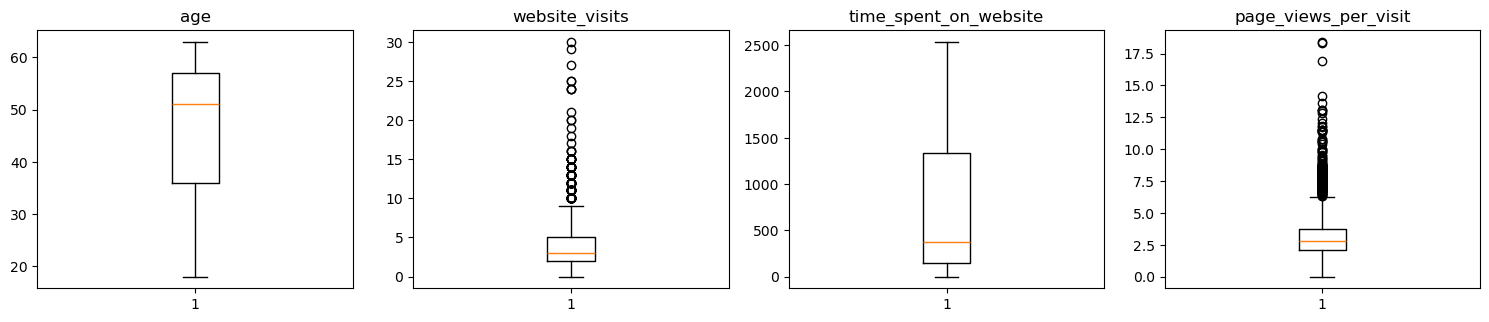

In [50]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
# dropping release_year as it is a temporal variable
numeric_columns.remove("status")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

## Data Preparation

In [51]:
# Encode categoricals
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

In [52]:
X = df.drop(["status"], axis=1)
Y = df["status"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [54]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3228, 13)
Shape of test set :  (1384, 13)
Percentage of classes in training set:
status
0    0.704151
1    0.295849
Name: proportion, dtype: float64
Percentage of classes in test set:
status
0    0.695087
1    0.304913
Name: proportion, dtype: float64


In [55]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Training Models

In [56]:
models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "NaiveBayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVC (RBF Kernel)": SVC(probability=True, kernel='rbf'),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, random_state=42)
}


In [57]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, model.predict_proba(X_test)[:,1]),
        "f1": f1_score(y_test, y_pred)
    }
    print(f"\n{name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


LogisticRegression
Confusion Matrix:
 [[866  96]
 [164 258]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87       962
           1       0.73      0.61      0.66       422

    accuracy                           0.81      1384
   macro avg       0.78      0.76      0.77      1384
weighted avg       0.81      0.81      0.81      1384


RandomForest
Confusion Matrix:
 [[886  76]
 [127 295]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.90       962
           1       0.80      0.70      0.74       422

    accuracy                           0.85      1384
   macro avg       0.83      0.81      0.82      1384
weighted avg       0.85      0.85      0.85      1384


XGBoost
Confusion Matrix:
 [[869  93]
 [122 300]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89       

In [58]:
df_results = pd.DataFrame(results).T
df_results

,accuracy,roc_auc,f1
LogisticRegression,0.812139,0.849020,0.664948
RandomForest,0.853324,0.915577,0.744010
XGBoost,0.844653,0.915905,0.736196
NaiveBayes,0.757948,0.817956,0.470774
KNN,0.820809,0.831034,0.684478
SVC (RBF Kernel),0.826590,0.877926,0.696970
MLPClassifier,0.810694,0.862990,0.671679


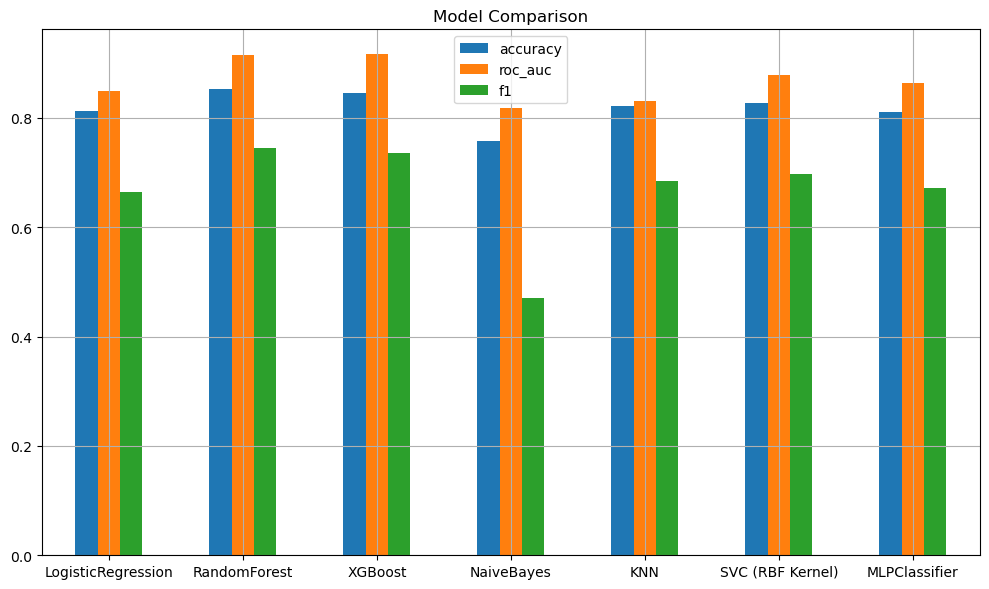

In [59]:
df_results.plot(kind="bar", figsize=(10,6), title="Model Comparison")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations:**
- Random Forest is the top-performing model, demonstrating the highest accuracy (0.853) and F1-score (0.744). Its ROC AUC (0.916) is also excellent, indicating a strong ability to distinguish between positive and negative classes.

- XGBoost is a close second. It achieved a slightly higher ROC AUC (0.916) than Random Forest, though its accuracy and F1-score are marginally lower. Both of these ensemble-based models are highly effective.

- Naive Bayes is the least effective model, with the lowest scores for accuracy (0.758), ROC AUC (0.818), and F1-score (0.471). The low F1-score suggests it struggles with the balance between precision and recall, which is often a sign of poor performance on imbalanced datasets.

- Other Models like Logistic Regression, KNN, SVC, and MLPClassifier perform reasonably well, but they fall short of the high standards set by Random Forest and XGBoost.

## Explainability 

In [60]:
best_model = models["RandomForest"]

In [61]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

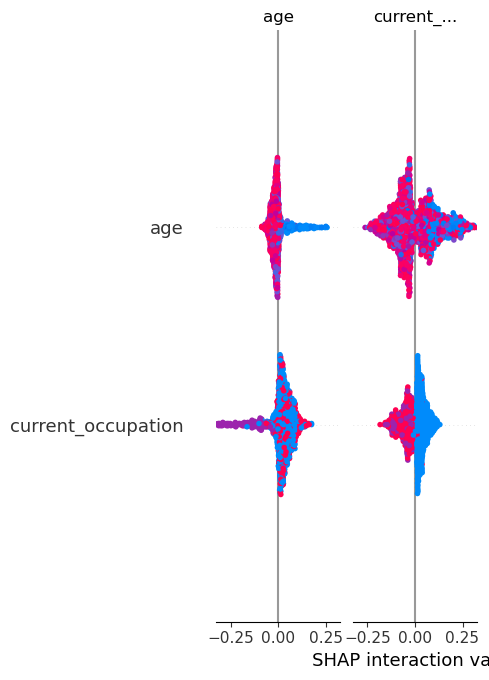

In [62]:
# SHAP Summary Plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

In [63]:
shap_interaction_values = explainer.shap_interaction_values(X_test)

In [ ]:
# Extract interaction values for class 1
shap_interaction_class1 = shap_interaction_values[:, :, :, 1]

In [68]:
shap_interaction_class1.shape

(1384, 13, 13)

In [70]:
shap_values_main_class1 = shap_interaction_class1.sum(axis=2)

In [71]:
shap_values_main_class1.shape

(1384, 13)

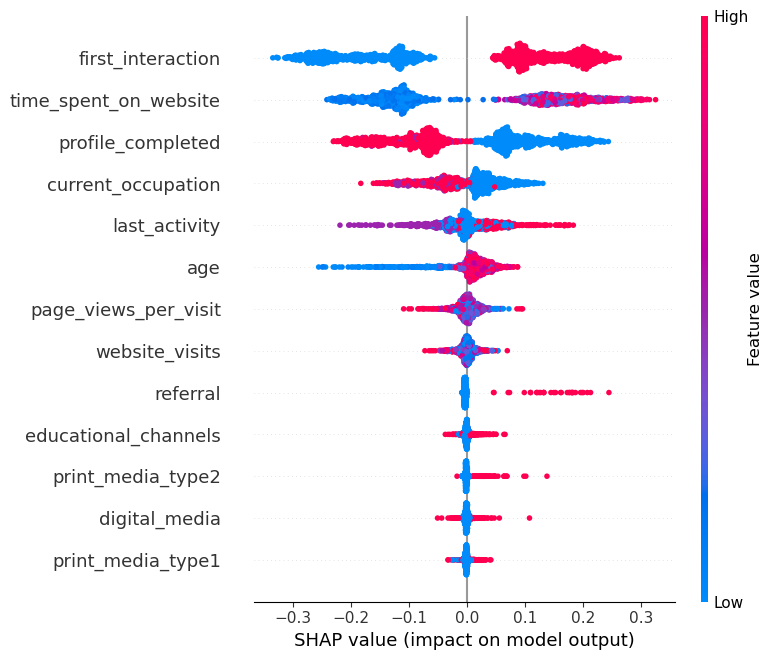

In [73]:
shap.summary_plot(shap_values_main_class1, X_test, feature_names=X.columns.tolist())

**Observations:**
- Top Predictors: first_interaction and time_spent_on_website are by far the most influential features. Their SHAP values have the widest spread, indicating they have the biggest impact on the model's predictions.

 - first_interaction: Low values (blue dots) push the model's output significantly lower, while high values (red dots) push it much higher. This confirms our earlier finding that the channel of the first interaction is a critical differentiator.

 - time_spent_on_website: Low values (blue dots) have a strong negative impact on conversion likelihood, and high values (red dots) have a strong positive impact. This validates the finding that deep engagement is more important than the number of visits.


- profile_completed: High values (red dots) push the model's output lower, while low values (blue dots) push it higher. This seems counterintuitive and suggests that a low profile completion might be a proxy for a certain type of customer, or that the model has learned a complex, non-linear relationship. Further investigation is needed here.

- current_occupation and last_activity: These features also have a notable impact on the model's output, with a mix of positive and negative effects depending on their values.

- Least Important Features: Features like educational_channels, print_media_type2, digital_media, and print_media_type1 have SHAP values clustered around zero. This confirms our earlier analysis that these channels have very little influence on whether a customer converts or not.


The SHAP Interaction Plot shows a strong amplifying effect when age and current_occupation have similar values.

 - High-Value Combination: When both age (red dots) and current_occupation have high values, their combined interaction pushes the model's output significantly higher.

 - Low-Value Combination: When both have low values (blue dots), their combined interaction also pushes the model's output higher.

 - Mixed Values: The interaction is minimal when the values are mixed (e.g., high age and low occupation), with SHAP values near zero. This confirms that these two features are most powerful in combination, especially when their values are aligned.

**Final Conclusion:**
The most critical factors driving customer conversion are first_interaction, time_spent_on_website, and the age/current_occupation combination. Your model has correctly identified that deep engagement and the entry point of the customer journey are more important than superficial metrics like website visits. The model has also discovered that certain customer segments, defined by the interaction between age and current_occupation, are particularly likely to convert. Conversely, most of your media and educational channels have a negligible impact on conversion.

**Key Business Insights**
- Deep Engagement is Crucial: The most significant predictors of conversion are time_spent_on_website and first_interaction. A user's time on the site is a better indicator of conversion intent than the number of pages they view or the number of times they visit.

- Website Outperforms Mobile App: Customers who first interact with the business through the website have a significantly higher conversion rate than those who use the mobile app. This suggests a need to improve the mobile app user experience.

- Target the Professional Demographic: Professionals are the most likely group to convert. The model shows that age and current_occupation work together to identify high-potential customers, particularly in the older professional demographic.

- Ineffective Marketing Channels: Traditional marketing channels like print media and digital media have a negligible impact on conversion. Your resources are likely better spent on other strategies.

- Focus on Referrals: While a small group, referred customers have a very high conversion rate. This indicates that a strong referral program could be a highly effective way to acquire valuable customers.

- Profile Completion Indicates Intent: Users who complete a high or medium amount of their profile are more likely to convert. This suggests that the willingness to provide information is a good proxy for genuine interest.

**Actionable Recommendations**
- Optimize the Website Experience: Since time spent on the website and the first interaction are so important, invest in A/B testing and user experience (UX) design to increase engagement and guide new visitors towards key conversion points.

- Rethink the Mobile App Strategy: Investigate why the mobile app has a low conversion rate. Conduct user research to identify pain points and a redesign to make it more intuitive and effective.

- Develop Targeted Marketing Campaigns: Focus marketing efforts and ad spend on channels and messages that appeal specifically to the professional demographic.

- Launch a Referral Program: Create a formal referral program to capitalize on this highly effective, albeit small, customer acquisition channel.

- Streamline Communication: Since last_activity on the website is a strong predictor, use automated email campaigns or notifications to bring customers back to the site rather than relying on phone calls as a last-ditch effort.